In [2]:
import os, sys
from pathlib import Path

cur_dir = os.getcwd()
path = Path(cur_dir)
sys.path.insert(0, str(path.parent.absolute()))

import pandas as pd
import pickle
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from src.preprocess import preprocess_df
from src.network_model import NetworkModel
from src.analyze_cic_ids import nre_classification, flow_based_classification
from src.classification_tools import plot_roc_curves

from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB


In [3]:
file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Tuesday-WorkingHours.pcap_ISCX.csv'  # 'Monday-WorkingHours.pcap_ISCX.csv' #  Wednesday-workingHours.pcap_ISCX.csv
file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv'
#file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv'
#file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Friday-WorkingHours-Morning.pcap_ISCX.csv'
#file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv'
#file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'
df_cic = pd.read_csv(file_addr, header=0, encoding='cp1252')

df = preprocess_df(df_cic, date_col=' Timestamp')
print(df.shape)

C:\Users\bayer\AppData\Local\Temp\ipykernel_7184\514327465.py:7: DtypeWarning: Columns (0,1,3,6,84) have mixed types. Specify dtype option on import or set low_memory=False.
  df_cic = pd.read_csv(file_addr, header=0, encoding='cp1252')


(170231, 85)


In [4]:
np.unique(df[' Label'].values, return_counts= True)

(array(['BENIGN', 'Web Attack – Brute Force', 'Web Attack – Sql Injection',
        'Web Attack – XSS'], dtype=object),
 array([168051,   1507,     21,    652], dtype=int64))

In [5]:
with open('victim_net.pickle', 'rb') as handle:
    entity_names = pickle.load(handle) 
len(entity_names)

UnpicklingError: invalid load key, '\xef'.

In [5]:
with open('partitioned_nodes_106.pickle', 'rb') as handle:
    subnet_names = pickle.load(handle) 
len(subnet_names)

106

Conditioning number:  49.56134634470449 
Determinant of F^T*F:  0.07451618265912748


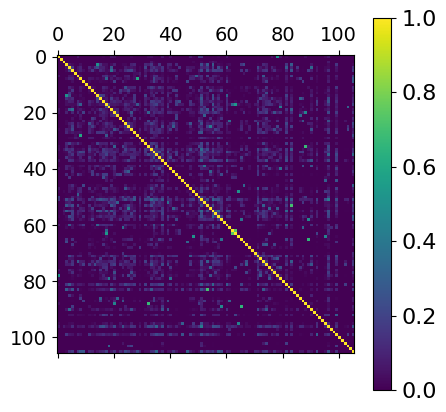

In [49]:
nm = NetworkModel()
nm.read_flows(df, conn_param='Num Packets Received', entity_names=subnet_names,
             window_type= 'time', sync_window_size= 20, time_scale= 'sec')

nm.fit_graph_model(method = 'cov') # cov
nm.plot_f()

In [27]:
models = {'Linear Support Vector Machines': LinearSVC(dual='auto'), 'Decision Trees': DecisionTreeClassifier(),
          'Random Forest': RandomForestClassifier(), 'Naive Bayes': GaussianNB()}
t_graph = 90  # s, 60
labelling_opt = 'attacks first'
conn_param = 'Num Packets Received'#'Num Packets Rec'
feat_cols = (' Total Fwd Packets', ' Total Backward Packets')

nre_curves = {}
df_nre = nre_classification(df, models, entity_names=subnet_names, t_graph=t_graph,
                            conn_param=conn_param, sync_window_size=1.2, verbose=True, roc_curves=nre_curves, seed=30)
print(df_nre)

1
Current time and samples shape:  2017-04-07 01:02:00 (75, 106)
2
Current time and samples shape:  2017-04-07 01:04:00 (75, 106)
3
Current time and samples shape:  2017-04-07 01:06:00 (75, 106)
4
Current time and samples shape:  2017-04-07 01:08:00 (75, 106)
5
Current time and samples shape:  2017-04-07 01:10:00 (75, 106)
6
Current time and samples shape:  2017-04-07 01:12:00 (75, 106)
7
Current time and samples shape:  2017-04-07 01:14:00 (75, 106)
8
Current time and samples shape:  2017-04-07 01:16:00 (75, 106)
9
Current time and samples shape:  2017-04-07 01:18:00 (75, 106)
10
Current time and samples shape:  2017-04-07 01:20:00 (75, 106)
11
Current time and samples shape:  2017-04-07 01:22:00 (75, 106)
12
Current time and samples shape:  2017-04-07 01:24:00 (75, 106)
13
Current time and samples shape:  2017-04-07 01:26:00 (75, 106)
14
Current time and samples shape:  2017-04-07 01:28:00 (75, 106)
15
Current time and samples shape:  2017-04-07 01:30:00 (75, 106)
16
Current time and

125
Current time and samples shape:  2017-04-07 09:01:00 (75, 106)
126
Current time and samples shape:  2017-04-07 09:03:00 (75, 106)
127
Current time and samples shape:  2017-04-07 09:05:00 (75, 106)
128
Current time and samples shape:  2017-04-07 09:07:00 (75, 106)
129
Current time and samples shape:  2017-04-07 09:09:00 (75, 106)
130
Current time and samples shape:  2017-04-07 09:11:00 (75, 106)
131
Current time and samples shape:  2017-04-07 09:13:00 (75, 106)
132
Current time and samples shape:  2017-04-07 09:15:00 (75, 106)
133
Current time and samples shape:  2017-04-07 09:17:00 (75, 106)
134
Current time and samples shape:  2017-04-07 09:19:00 (75, 106)
135
Current time and samples shape:  2017-04-07 09:21:00 (75, 106)
136
Current time and samples shape:  2017-04-07 09:23:00 (75, 106)
137
Current time and samples shape:  2017-04-07 09:25:00 (75, 106)
138
Current time and samples shape:  2017-04-07 09:27:00 (75, 106)
139
Current time and samples shape:  2017-04-07 09:29:00 (75, 

In [28]:
import importlib
import src.classification_tools

importlib.reload(src.classification_tools)
from src.classification_tools import *

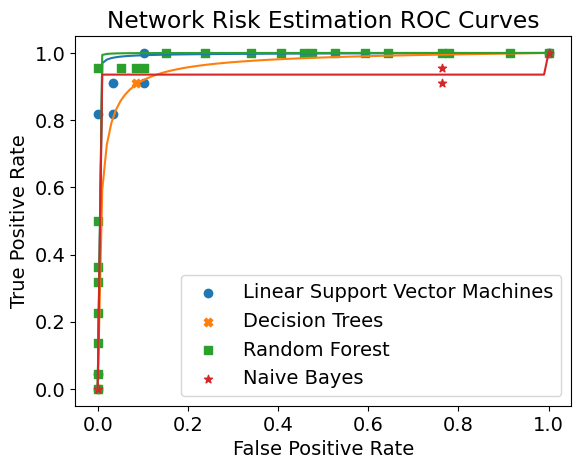

In [35]:
fig1 = plot_roc_curves(nre_curves, title='Network Risk Estimation ROC Curves')

In [30]:
flow_based_curves = {}
df_flow_based = flow_based_classification(df, models, entity_names=entity_names, t_graph=t_graph,
                                          feat_cols = (' Total Fwd Packets', ' Total Backward Packets'),
                                          roc_curves=flow_based_curves, seed=30)
print(df_flow_based)

                                Accuracy  Precision    Recall   
Linear Support Vector Machines  0.777778   0.625000  0.454545  \
Decision Trees                  0.271605   0.271605  1.000000   
Random Forest                   0.271605   0.271605  1.000000   
Naive Bayes                     0.444444   0.317460  0.909091   

                                Balanced Accuracy        f1  
Linear Support Vector Machines           0.676425  0.526316  
Decision Trees                           0.500000  0.427184  
Random Forest                            0.500000  0.427184  
Naive Bayes                              0.590139  0.470588  


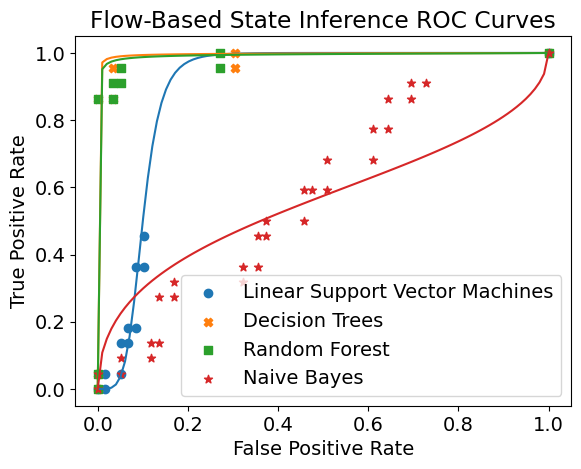

In [34]:
fig2 = plot_roc_curves(flow_based_curves, title='Flow-Based State Inference ROC Curves')

In [37]:
import importlib
import src.analyze_cic_ids

importlib.reload(src.analyze_cic_ids)
from src.analyze_cic_ids import *

In [38]:
from src.analyze_cic_ids import compare_among_conn_params

all_df = compare_among_conn_params(df, subnet_names, entity_names, t_graph=90, sync_window_size=1.2, best_op_point=True, seed=30)

 18%|████████████████████▎                                                                                           | 2/11 [08:34<38:28, 256.50s/it]C:\Users\bayer\PycharmProjects\NRE\venv2\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\bayer\PycharmProjects\NRE\venv2\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
 27%|██████████████████████████████▌                                                                                 | 3/11 [13:11<35:29, 266.13s/it]C:\Users\bayer\PycharmProjects\NRE\venv2\lib\site-packages\sklearn\metrics\_classi

In [39]:
import pickle

with open('sweep_tuesday_internal_90_1_2.pickle', 'wb') as handle:
    pickle.dump(all_df, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [ ]:
with open('sweep_tuesday_internal_180_1_2.pickle', 'rb') as handle:
    all_df = pickle.load(handle)

In [ ]:
all_df

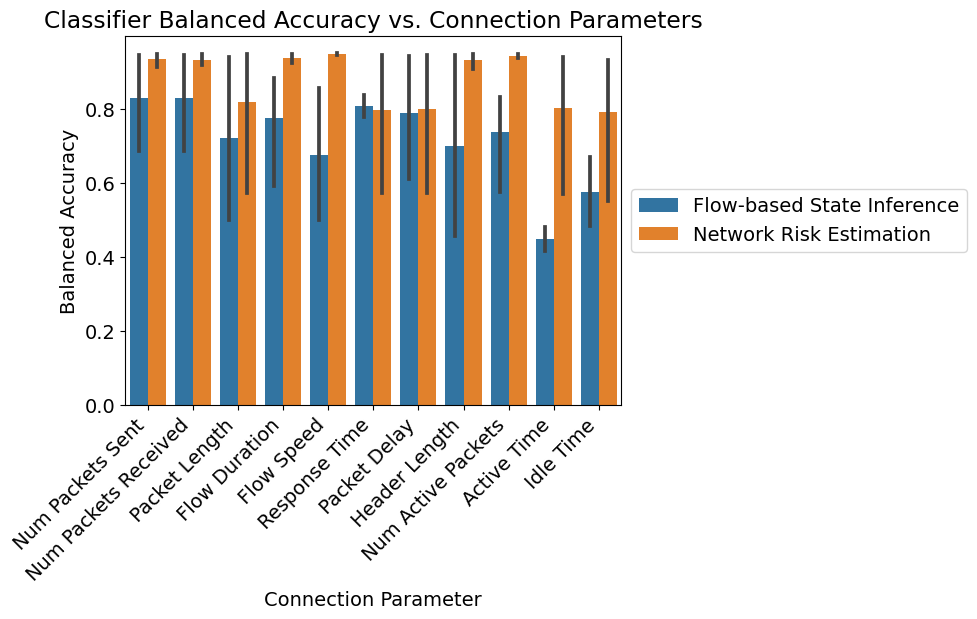

In [40]:
from src.analyze_cic_ids import plot_perf_comparison


fig = plot_perf_comparison(all_df, title='Classifier Balanced Accuracy vs. Connection Parameters', peak_only=False)


# Miscellaneous

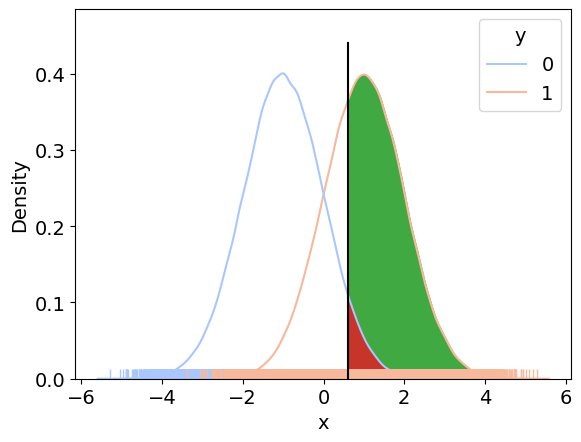

In [187]:
from scipy.stats import norm

from_sample = True
N = 100_000
plot_op, plot_thr = True, True
t = 0.6
plt.rcParams.update({'font.size': 14})

if not from_sample:
    xs1 = np.linspace(-4.5, 4.5, 2000)
    xs0 = xs1
    pdf0 = norm.pdf(xs0, -1, 1)
    pdf1 = norm.pdf(xs1, 1, 1)
    
    plt.plot(xs0, pdf0, label='0', color="tab:blue")
    plt.plot(xs1, pdf1, label='1', color="tab:red")
    plt.xlabel('x')
    plt.legend()
    ax = plt.gca()
else:
    x0 = np.random.normal(-1, 1, N)
    x1 = np.random.normal(1, 1, N)
    df = pd.DataFrame({'x':x0, 'y':0})
    df = pd.concat((df, pd.DataFrame({'x':x1, 'y':1})))
    
    sns.kdeplot(data=df, x="x", hue="y", palette="coolwarm", common_norm=False)
    sns.rugplot(data=df, x="x", hue="y", palette="coolwarm")#, clip_on=False, height=-.02,)
    ax = plt.gca()
    li1, li0 = ax.lines[0], ax.lines[1]
    xs0  = li0.get_data()[0]
    pdf0 = li0.get_data()[1]
    xs1  = li1.get_data()[0]
    pdf1 = li1.get_data()[1]

if plot_thr:
    ax.plot([t, t], [0, ax.get_ylim()[1]], 'k')
    
    if plot_op:
        # True Positive
        ind = xs1 > t
        plt.fill_between(xs1[ind], pdf1[ind], 0, color='tab:green', alpha=0.9)
        
        # False Positives
        ind = xs0 > t
        plt.fill_between(xs0[ind], pdf0[ind], color='tab:red', alpha=0.9)

        



Text(0, 0.5, 'TPR')

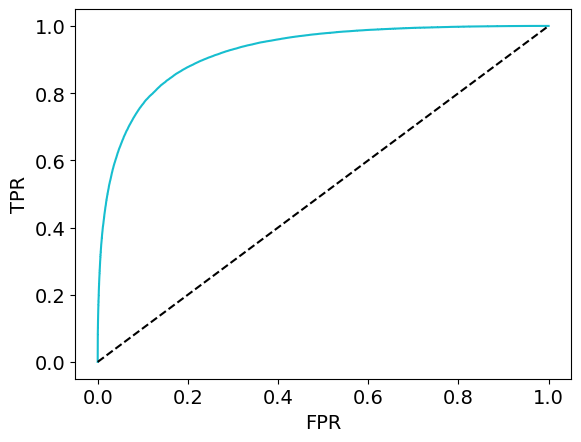

In [189]:
from sklearn.metrics import roc_curve

ax = plt.subplot()
fpr, tpr, thresholds = roc_curve(df['y'], df['x'])
ax.plot(fpr, tpr, color='tab:cyan')
ax.plot([0,1], [0,1], linestyle='dashed',  color='k')
plt.xlabel('FPR')
plt.ylabel('TPR')

Text(0, 0.5, 'TPR')

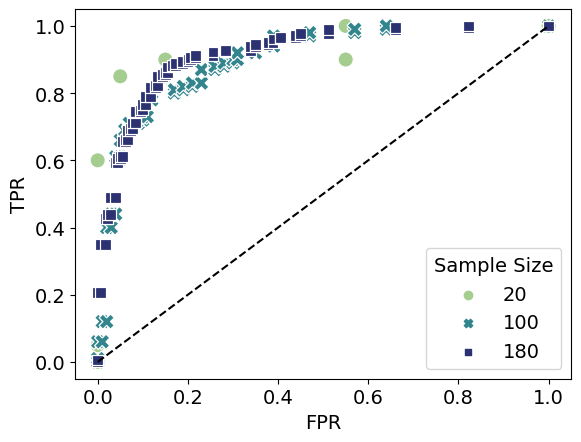

In [186]:
from sklearn.metrics import roc_curve

ax = plt.subplot()
all_df = pd.DataFrame()
for N in np.arange(20, 200, 80):
    x0 = np.random.normal(-1, 1, N)
    x1 = np.random.normal(1, 1, N)
    df = pd.DataFrame({'x':x0, 'y':0})
    df = pd.concat((df, pd.DataFrame({'x':x1, 'y':1})))
    fpr, tpr, thresholds = roc_curve(df['y'], df['x'])
    
    temp_df = pd.DataFrame({'FPR': fpr, 'TPR':tpr, 'Sample Size': N})
    all_df = pd.concat((all_df, temp_df))
    #ax.scatter(fpr, tpr, 'o', label=str(N))
    
sns.scatterplot(data=all_df, x='FPR', y='TPR', hue='Sample Size', style='Sample Size', s=120, ax=ax, palette='crest')
ax.plot([0,1], [0,1], linestyle='dashed',  color='k')    
plt.xlabel('FPR')
plt.ylabel('TPR')
#plt.legend()

In [161]:
np.arange(20, 30, 2)

array([20, 22, 24, 26, 28])